In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

df = pd.read_csv('circles.csv')
df.head(2)

,0,1
0,0.393992,-0.416376
1,0.528243,-0.828242


[]

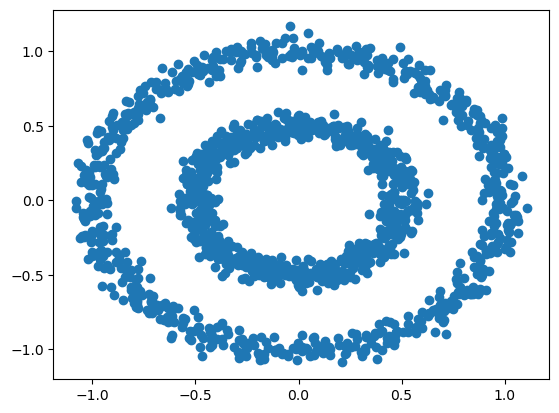

In [3]:
plt.scatter(df.iloc[0:, 0], df.iloc[0:, 1])
plt.plot()

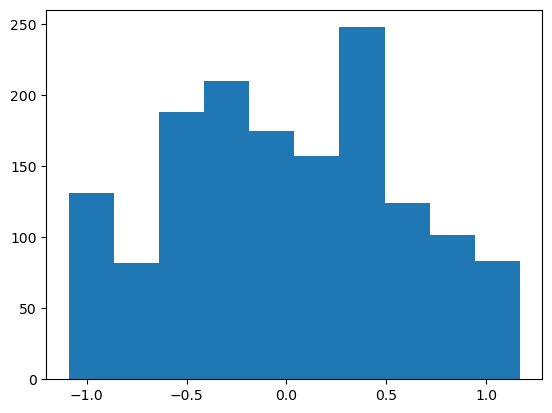

In [4]:
plt.hist(df.iloc[0:, 1])
plt.show()

In [5]:
from sklearn.cluster import KMeans

In [6]:
###################################
# 1. Iterate all possible `k`s, find min(distance of points to centernoid of each cluster)
#    that is stored in est_kmeans.inertia_
#
k_max = 20
ideal_k = []
# range() is an upper bound exclusive func.
for i in range(1, k_max + 1):
    est_kmeans = KMeans(n_clusters = i, random_state = 0)
    est_kmeans.fit(df)
    ideal_k.append([i, est_kmeans.inertia_])

print(ideal_k)

[[1, 947.0693750197635], [2, 602.2689734788721], [3, 363.94997788954373], [4, 258.7886514078296], [5, 202.5302593890464], [6, 170.7461946649875], [7, 155.3526343600599], [8, 137.75411675408876], [9, 119.85792603377183], [10, 103.85545172571274], [11, 91.21970276691151], [12, 76.70326125594471], [13, 64.73785203890995], [14, 57.06609017838211], [15, 50.636973365330945], [16, 43.31641960629378], [17, 38.99270638416903], [18, 35.06795842431768], [19, 32.41707037045042], [20, 29.82707578360115]]


In [7]:
###################################
# 2. Convert list to numpy.array
#
print(type(ideal_k))
ideal_k = np.array(ideal_k)
print(type(ideal_k))
print(ideal_k)

<class 'list'>
<class 'numpy.ndarray'>
[[  1.         947.06937502]
 [  2.         602.26897348]
 [  3.         363.94997789]
 [  4.         258.78865141]
 [  5.         202.53025939]
 [  6.         170.74619466]
 [  7.         155.35263436]
 [  8.         137.75411675]
 [  9.         119.85792603]
 [ 10.         103.85545173]
 [ 11.          91.21970277]
 [ 12.          76.70326126]
 [ 13.          64.73785204]
 [ 14.          57.06609018]
 [ 15.          50.63697337]
 [ 16.          43.31641961]
 [ 17.          38.99270638]
 [ 18.          35.06795842]
 [ 19.          32.41707037]
 [ 20.          29.82707578]]


In [8]:
ideal_k[:, 0]

array([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13.,
       14., 15., 16., 17., 18., 19., 20.])

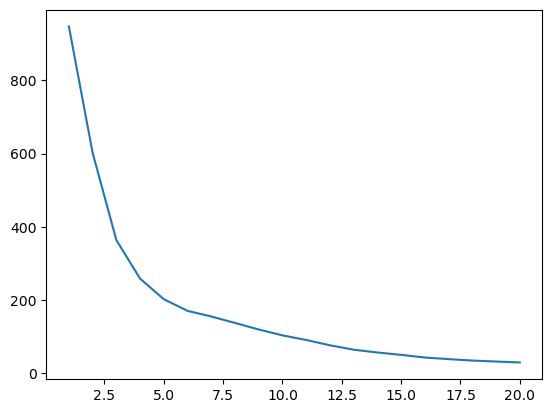

In [9]:
###################################
# 3. Plot min(dist(c, x)2)
#
plt.plot(ideal_k[:,0],ideal_k[:,1])
plt.show()

In [10]:
###################################
# 4. The breaking point of the plot is around k = 5
#
est_kmeans = KMeans(n_clusters = 5, random_state = 0)
est_kmeans.fit(df)
pred_kmeans = est_kmeans.predict(df)
print(pred_kmeans)

[2 2 3 ... 2 2 4]


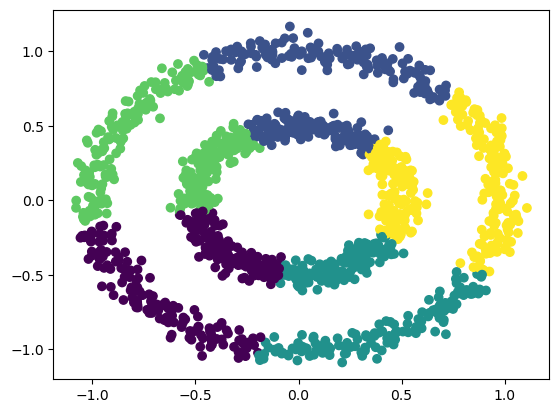

In [11]:
###################################
# 5. It is only possible to display up to 3 features.
#
plt.scatter(df.iloc[:, 0], df.iloc[:, 1], c = pred_kmeans)
plt.show()

In [12]:
###################################
# 6 MeanShift
#

from sklearn.cluster import MeanShift

In [13]:
###################################
# 7. fit and predict
#

est_meanshift = MeanShift(bandwidth = 0.5)
est_meanshift.fit(df)
pred_meanshift = est_meanshift.predict(df)

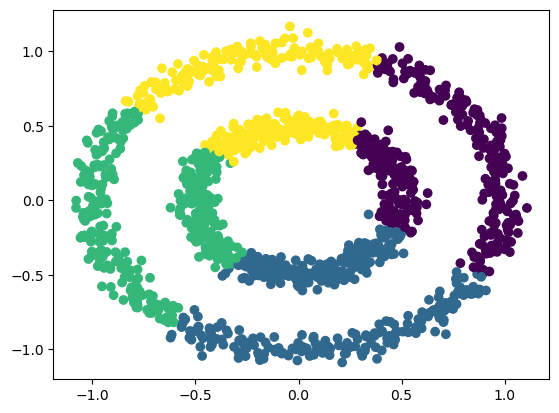

In [14]:
plt.scatter(df.iloc[:, 0], df.iloc[:, 1], c = pred_meanshift)
plt.show()

In [15]:
###################################
# 8. DBSCAN
#

from sklearn.cluster import DBSCAN

In [16]:
###################################
# 9. estimter, predictor, tranformer
#

est_dbscan = DBSCAN(eps = 0.2)
pred_dbscan = est_dbscan.fit_predict(df)

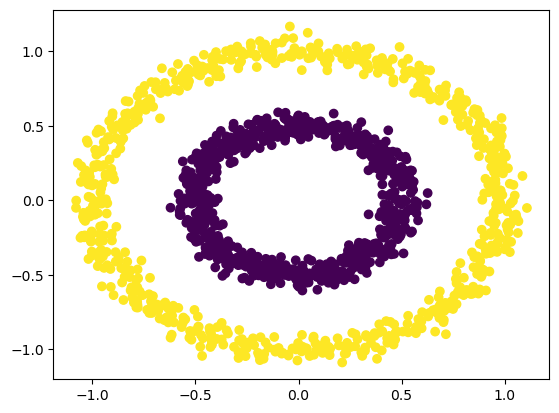

In [17]:
###################################
# 10. plot
#
plt.scatter(df.iloc[:, 0], df.iloc[:, 1], c = pred_dbscan)
plt.show()